# *Data Cleaning*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [2]:
df=pd.read_csv("stroke_prediction_dataset.csv")
df.head()

,Patient ID,Patient Name,Age,Gender,Hypertension,Heart Disease,Marital Status,Work Type,Residence Type,Average Glucose Level,Body Mass Index (BMI),Smoking Status,Alcohol Intake,Physical Activity,Stroke History,Family History of Stroke,Dietary Habits,Stress Levels,Blood Pressure Levels,Cholesterol Levels,Symptoms,Diagnosis
0,18153,Mamooty Khurana,56,Male,0,1,Married,Self-employed,Rural,130.91,22.37,Non-smoker,Social Drinker,Moderate,0,Yes,Vegan,3.48,140/108,"HDL: 68, LDL: 133","Difficulty Speaking, Headache",Stroke
1,62749,Kaira Subramaniam,80,Male,0,0,Single,Self-employed,Urban,183.73,32.57,Non-smoker,Never,Low,0,No,Paleo,1.73,146/91,"HDL: 63, LDL: 70","Loss of Balance, Headache, Dizziness, Confusion",Stroke
2,32145,Dhanush Balan,26,Male,1,1,Married,Never Worked,Rural,189.00,20.32,Formerly Smoked,Rarely,High,0,Yes,Paleo,7.31,154/97,"HDL: 59, LDL: 95","Seizures, Dizziness",Stroke
3,6154,Ivana Baral,73,Male,0,0,Married,Never Worked,Urban,185.29,27.50,Non-smoker,Frequent Drinker,Moderate,0,No,Paleo,5.35,174/81,"HDL: 70, LDL: 137","Seizures, Blurred Vision, Severe Fatigue, Head...",No Stroke
4,48973,Darshit Jayaraman,51,Male,1,1,Divorced,Self-employed,Urban,177.34,29.06,Currently Smokes,Rarely,Low,0,Yes,Pescatarian,6.84,121/95,"HDL: 65, LDL: 68",Difficulty Speaking,Stroke


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient ID                15000 non-null  int64  
 1   Patient Name              15000 non-null  object 
 2   Age                       15000 non-null  int64  
 3   Gender                    15000 non-null  object 
 4   Hypertension              15000 non-null  int64  
 5   Heart Disease             15000 non-null  int64  
 6   Marital Status            15000 non-null  object 
 7   Work Type                 15000 non-null  object 
 8   Residence Type            15000 non-null  object 
 9   Average Glucose Level     15000 non-null  float64
 10  Body Mass Index (BMI)     15000 non-null  float64
 11  Smoking Status            15000 non-null  object 
 12  Alcohol Intake            15000 non-null  object 
 13  Physical Activity         15000 non-null  object 
 14  Stroke

## *Handel Missing Vlaues*

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_report = pd.DataFrame({
'Missing Count' : missing,
'Missing %'     : missing_pct
}).query('`Missing Count` > 0')

print("Missing Values:")
print(quality_report.to_string())
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing Values:
          Missing Count  Missing %
Symptoms           2500      16.67
Duplicate rows: 0


In [5]:
df['Symptoms'].fillna(df['Symptoms'].mode()[0], inplace=True)

In [6]:
df.isnull().sum()

Patient ID                  0
Patient Name                0
Age                         0
Gender                      0
Hypertension                0
Heart Disease               0
Marital Status              0
Work Type                   0
Residence Type              0
Average Glucose Level       0
Body Mass Index (BMI)       0
Smoking Status              0
Alcohol Intake              0
Physical Activity           0
Stroke History              0
Family History of Stroke    0
Dietary Habits              0
Stress Levels               0
Blood Pressure Levels       0
Cholesterol Levels          0
Symptoms                    0
Diagnosis                   0
dtype: int64

In [7]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

Patient Name: ['Mamooty Khurana' 'Kaira Subramaniam' 'Dhanush Balan' ... 'Ivana Kaur'
 'Anvi Mannan' 'Gokul Trivedi']
Gender: ['Male' 'Female']
Marital Status: ['Married' 'Single' 'Divorced']
Work Type: ['Self-employed' 'Never Worked' 'Private' 'Government Job']
Residence Type: ['Rural' 'Urban']
Smoking Status: ['Non-smoker' 'Formerly Smoked' 'Currently Smokes']
Alcohol Intake: ['Social Drinker' 'Never' 'Rarely' 'Frequent Drinker']
Physical Activity: ['Moderate' 'Low' 'High']
Family History of Stroke: ['Yes' 'No']
Dietary Habits: ['Vegan' 'Paleo' 'Pescatarian' 'Gluten-Free' 'Vegetarian' 'Non-Vegetarian'
 'Keto']
Blood Pressure Levels: ['140/108' '146/91' '154/97' ... '157/103' '112/104' '100/69']
Cholesterol Levels: ['HDL: 68, LDL: 133' 'HDL: 63, LDL: 70' 'HDL: 59, LDL: 95' ...
 'HDL: 31, LDL: 125' 'HDL: 74, LDL: 123' 'HDL: 35, LDL: 183']
Symptoms: ['Difficulty Speaking, Headache'
 'Loss of Balance, Headache, Dizziness, Confusion' 'Seizures, Dizziness'
 ...
 'Numbness, Blurred Vision, 

# *Handle Column Values & Encoding*

In [8]:
def safe_convert_bp(value):
        try:
            return float(value)
        except:
            try:
                return float(ast.literal_eval(str(value)))
            except:
                return np.nan

df['Blood Pressure Levels'] = df['Blood Pressure Levels'].apply(safe_convert_bp).round(2)

## Cholesterol Levels Column


In [9]:
cholesterol_data = df['Cholesterol Levels'].str.extract(
        r'HDL:\s*(\d+),\s*LDL:\s*(\d+)'
    )
df['HDL'] = pd.to_numeric(cholesterol_data[0], errors='coerce')
df['LDL'] = pd.to_numeric(cholesterol_data[1], errors='coerce')

## Symptoms- Multi-Label Encoding

In [10]:

df['Symptoms'] = df['Symptoms'].apply(
        lambda x: [i.strip() for i in str(x).split(',')] if pd.notna(x) else []
    )
    
mlb = MultiLabelBinarizer()
symptoms_encoded = pd.DataFrame(
        mlb.fit_transform(df['Symptoms']),
        columns=[f'Symptom_{col}' for col in mlb.classes_],
        index=df.index
    )
    
df = pd.concat([df, symptoms_encoded], axis=1)

## Remove Column

In [11]:

cols_to_drop = ['Patient Name', 'Patient ID', 'Blood Pressure Levels', 
                'Cholesterol Levels', 'Symptoms']
df.drop(cols_to_drop, axis=1, inplace=True)

## Encoding

In [12]:

binary_map = {
    'Gender': {'Male': 1, 'Female': 0},
    'Residence Type': {'Urban': 1, 'Rural': 0},
    'Family History of Stroke': {'Yes': 1, 'No': 0},
    'Diagnosis': {'Stroke': 1, 'No Stroke': 0}
}

for col, mapping in binary_map.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)

# ordinal encoding
activity_map = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Physical Activity'] = df['Physical Activity'].map(activity_map)

# label encoding
label_cols = ['Marital Status', 'Work Type', 'Smoking Status', 
              'Alcohol Intake', 'Dietary Habits']

label_encoders = {}

for col in label_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le


## check and process outlier

In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

continuous_cols = [col for col in numeric_cols 
                   if df[col].nunique() > 10 and col != 'Diagnosis']

if continuous_cols:
    outliers_summary = []
    for col in continuous_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        outliers_pct = (outliers / len(df) * 100)
        
        if outliers > 0:
            outliers_summary.append({
                'Column': col,
                'Outliers': outliers,
                'Percentage': f"{outliers_pct:.2f}%",
                'Range': f"[{df[col].min():.2f}, {df[col].max():.2f}]"
            })
    
    if outliers_summary:
        outliers_df = pd.DataFrame(outliers_summary)
    else:
        print("No outliers detected in continuous features")

No outliers detected in continuous features


## final Data info

In [14]:
df.info()
print("\n" + "="*60)
print(f" rows: {df.shape[0]:,}")
print(f"  Columns: {df.shape[1]}")
print(f"  Missing Values: {df.isnull().sum().sum()}")
print(f"  Numeric Columns: {len(df.select_dtypes(include=[np.number]).columns)}")

display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          15000 non-null  int64  
 1   Gender                       15000 non-null  int64  
 2   Hypertension                 15000 non-null  int64  
 3   Heart Disease                15000 non-null  int64  
 4   Marital Status               15000 non-null  int64  
 5   Work Type                    15000 non-null  int64  
 6   Residence Type               15000 non-null  int64  
 7   Average Glucose Level        15000 non-null  float64
 8   Body Mass Index (BMI)        15000 non-null  float64
 9   Smoking Status               15000 non-null  int64  
 10  Alcohol Intake               15000 non-null  int64  
 11  Physical Activity            15000 non-null  int64  
 12  Stroke History               15000 non-null  int64  
 13  Family History o

,Age,Gender,Hypertension,Heart Disease,Marital Status,Work Type,Residence Type,Average Glucose Level,Body Mass Index (BMI),Smoking Status,Alcohol Intake,Physical Activity,Stroke History,Family History of Stroke,Dietary Habits,Stress Levels,Diagnosis,HDL,LDL,Symptom_Blurred Vision,Symptom_Confusion,Symptom_Difficulty Speaking,Symptom_Dizziness,Symptom_Headache,Symptom_Loss of Balance,Symptom_Numbness,Symptom_Seizures,Symptom_Severe Fatigue,Symptom_Weakness
0,56,1,0,1,1,3,0,130.91,22.37,2,3,1,0,1,5,3.48,1,68,133,0,0,1,0,1,0,0,0,0,0
1,80,1,0,0,2,3,1,183.73,32.57,2,1,0,0,0,3,1.73,1,63,70,0,1,0,1,1,1,0,0,0,0
2,26,1,1,1,1,1,0,189.00,20.32,1,2,2,0,1,3,7.31,1,59,95,0,0,0,1,0,0,0,1,0,0
3,73,1,0,0,1,1,1,185.29,27.50,2,0,1,0,0,3,5.35,0,70,137,1,1,0,0,1,0,0,1,1,0
4,51,1,1,1,0,3,1,177.34,29.06,0,2,0,0,1,4,6.84,1,65,68,0,0,1,0,0,0,0,0,0,0


## Ploting

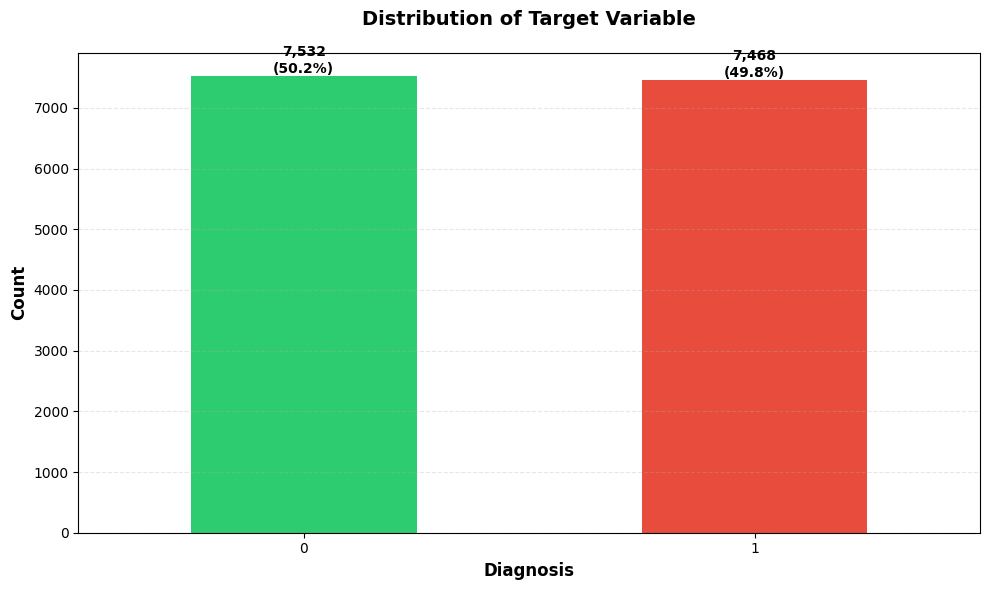

  0: 7,532 (50.21%)
  1: 7,468 (49.79%)


In [15]:

plt.figure(figsize=(10, 6))

counts = df['Diagnosis'].value_counts()
ax = counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'])

plt.xlabel("Diagnosis", fontsize=12, fontweight='bold')
plt.ylabel("Count", fontsize=12, fontweight='bold')
plt.title("Distribution of Target Variable", fontsize=14, fontweight='bold', pad=20)

for i, (idx, val) in enumerate(counts.items()):
    percentage = (val / counts.sum() * 100)
    ax.text(i, val, f'{val:,}\n({percentage:.1f}%)', 
        ha='center', va='bottom', fontweight='bold')
    
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

for label, count in counts.items():
        print(f"  {label}: {count:,} ({count/counts.sum()*100:.2f}%)")

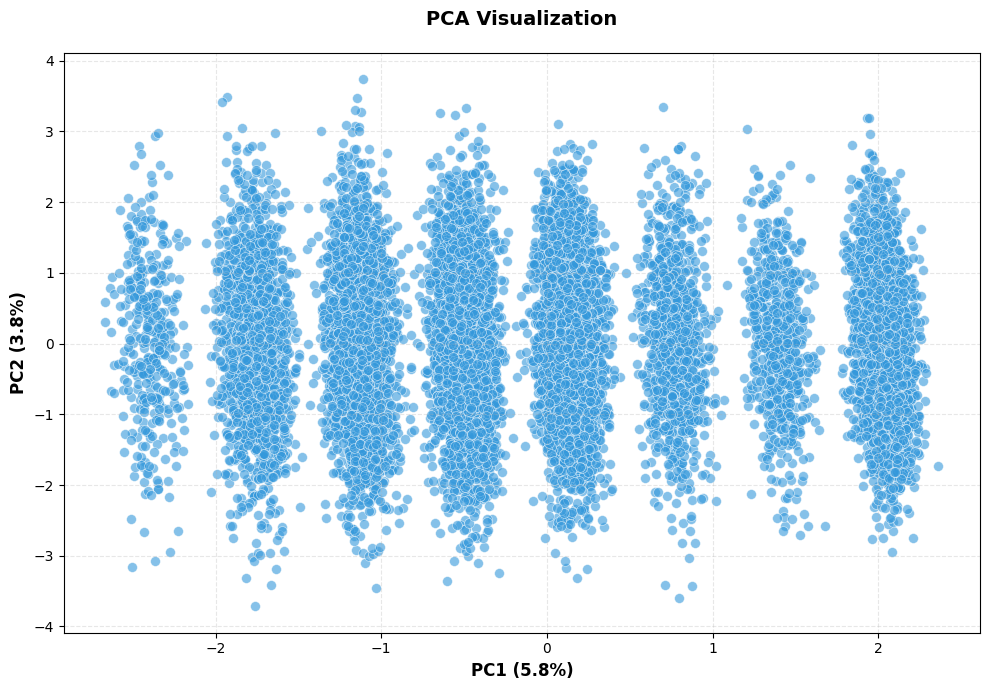

In [17]:

X = df.drop(columns=['Diagnosis'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c='#3498db',
    alpha=0.6,
    s=50,
    edgecolors='white',
    linewidth=0.5
)
plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    fontsize=12,
    fontweight='bold'
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
    fontsize=12,
    fontweight='bold'
)
plt.title(
    "PCA Visualization",
    fontsize=14,
    fontweight='bold',
    pad=20
)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()